In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

In [2]:
# Generate toy dataset
np.random.seed(42)
n_samples = 50

# Create training data from a known function with noise
X_train = np.random.uniform(0, 10, n_samples).reshape(-1, 1)
X_train = np.sort(X_train, axis=0)  # Sort for better visualization

# True function: combination of sine and linear trend
y_true = np.sin(X_train).ravel() + 0.1 * X_train.ravel()
# Add noise
y_train = y_true + np.random.normal(0, 0.15, n_samples)

In [3]:
# Define the kernel
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Create and fit the Gaussian Process model
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0.1)
gp.fit(X_train, y_train)

# Make predictions on a dense grid
X_test = np.linspace(-1, 11, 200).reshape(-1, 1)
y_pred, sigma = gp.predict(X_test, return_std=True)

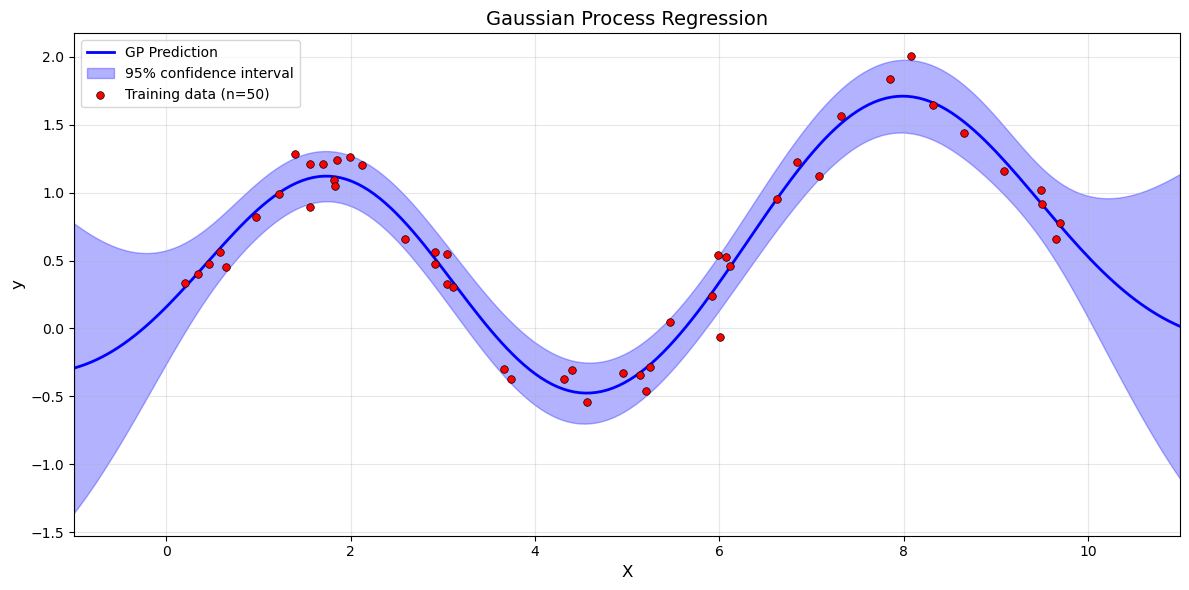

Training samples: 50
Optimized kernel: 0.982**2 * RBF(length_scale=1.74)
Log-marginal-likelihood: -8.436

Prediction uncertainty (std) range:
  Within training range: 0.117
  Outside training range: 0.558


In [4]:
# Plot results
plt.figure(figsize=(12, 6))
plt.plot(X_test, y_pred, 'b-', linewidth=2, label='GP Prediction')
plt.fill_between(X_test.ravel(), 
                 y_pred - 1.96*sigma, 
                 y_pred + 1.96*sigma, 
                 alpha=0.3, color='blue', label='95% confidence interval')
plt.scatter(X_train, y_train, c='red', s=30, zorder=10, 
            edgecolors='black', linewidth=0.5, label=f'Training data (n={n_samples})')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Gaussian Process Regression', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(-1, 11)
plt.tight_layout()
plt.show()

# Print statistics
print(f"Training samples: {n_samples}")
print(f"Optimized kernel: {gp.kernel_}")
print(f"Log-marginal-likelihood: {gp.log_marginal_likelihood_value_:.3f}")
print(f"\nPrediction uncertainty (std) range:")
print(f"  Within training range: {sigma[20:180].mean():.3f}")
print(f"  Outside training range: {sigma[[0, -1]].mean():.3f}")